In [71]:
import xarray as xr
from glob import glob
import numpy as np
import dask_image.ndfilters as dfilters
import dask.array as da
from braceexpand import braceexpand
import os
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import argparse
import cftime
import pandas as pd

In [72]:
def calc_grid_distance_area(longitude, latitude):
    """ Function to calculate grid parameters
        It uses haversine function to approximate distances
        It approximates the first row and column to the sencond
        because coordinates of grid cell center are assumed
        lat, lon: input coordinates(degrees) 2D [y,x] dimensions
        dx: distance (m)
        dy: distance (m)
        grid_distance: average grid distance over the domain (m)
    """

    if longitude.ndim < 2:
        lon, lat = np.meshgrid(longitude, latitude)
    else:
        lon, lat = longitude.values, latitude.values
    
    dy = np.zeros(lon.shape)
    dx = np.zeros(lat.shape)

    dx[:,1:]=haversine(lon[:,1:],lat[:,1:],lon[:,:-1],lat[:,:-1])
    dy[1:,:]=haversine(lon[1:,:],lat[1:,:],lon[:-1,:],lat[:-1,:])

    dx[:,0] = dx[:,1]
    dy[0,:] = dy[1,:]
    
    dx = dx * 10**3
    dy = dy * 10**3

    grid_distance = np.mean(np.append(dy[:, :, None], dx[:, :, None], axis=2))

    return grid_distance


def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

def convert_lon_lat(ds, var_lon, var_lat, to_180=True):
    """
    Convertit les coordonnées lon/lat sur une grille -180:180 ou 0:360.
    
    Args:
        ds (xarray.Dataset): Dataset d'entrée.
        var_lon (str): Nom de la dimension/variable longitude.
        var_lat (str): Nom de la dimension/variable latitude.
        to_180 (bool): Si True, convertit vers -180:180. 
                       Si False, convertit vers 0:360.
    """
    
    if ds[var_lon].ndim == 2:
        print('\nLongitude and Latitude are 2D arrays')
        
        if to_180:
            # Conversion vers -180:180
            if (ds[var_lon] >= 180.).any():
                ds[var_lon] = (((ds[var_lon] + 180) % 360) - 180)
                print('Longitude converted to -180:180 grid')
        else:
            # Conversion vers 0:360
            if (ds[var_lon] < 0.).any():
                ds[var_lon] = (ds[var_lon] % 360)
                print('Longitude converted to 0:360 grid')

        # La latitude reste généralement en -90:90, on garde ta logique de sécurité
        if (ds[var_lat] > 90.).any() or (ds[var_lat] < -90.).any():
            ds[var_lat] = (((ds[var_lat] + 90) % 180) - 90)
            print('Latitude converted to -90:90 grid')

    else:
        # Cas des coordonnées 1D
        if to_180:
            if any(ds[var_lon] >= 180.):
                ds = ds.assign_coords({var_lon: (((ds[var_lon] + 180) % 360) - 180)})
                print('Longitude converted to -180:180 grid')
        else:
            if any(ds[var_lon] < 0.):
                ds = ds.assign_coords({var_lon: (ds[var_lon] % 360)})
                print('Longitude converted to 0:360 grid')

        if any(ds[var_lat] > 90.) or any(ds[var_lat] < -90.):
            ds = ds.assign_coords({var_lat: (((ds[var_lat] + 90) % 180) - 90)})
            print('Latitude converted to -90:90 grid')

        # Réorganisation de la grille (important après conversion)
        ds = ds.sortby(ds[var_lon])

    # --- Vérifications (Assertions) adaptées ---
    if to_180:
        assert ds[var_lon].min() >= -180.0, 'Min longitude < -180'
        assert ds[var_lon].max() <= 180.0, 'Max longitude > 180'
    else:
        assert ds[var_lon].min() >= 0.0, 'Min longitude < 0'
        assert ds[var_lon].max() <= 360.0, 'Max longitude > 360'
        
    assert ds[var_lat].min() >= -90.0, 'Min latitude < -90'
    assert ds[var_lat].max() <= 90.0, 'Max latitude > 90'

    return ds

def get_mask(ds, var_lon, var_lat, west_longitude=-180, east_longitude=180, north_latitude=90, south_latitude=-90, plot=False):
    
    if ds[var_lon].ndim == 2:
        mask = (
                (ds[var_lon] >= west_longitude) &
                (ds[var_lon] <= east_longitude) &
                (ds[var_lat] >= south_latitude) &
                (ds[var_lat] <= north_latitude)
            )
        ds = ds.where(mask, drop=True)
        # ds = masked_ds.dropna(dim='rlon', how='all').dropna(dim='rlat', how='all') #pas nécessaire visiblement
        
    else:
        ds = ds.sel({var_lon: slice(west_longitude, east_longitude), var_lat: slice(north_latitude, south_latitude)})
    
    if plot==True:
        if ds[var_lon].ndim == 2:
            Mask = np.copy(ds[var_lon]); Mask[:]=1
            pole_lon = ds.rotated_pole.attrs['grid_north_pole_longitude']
            pole_lat = ds.rotated_pole.attrs['grid_north_pole_latitude']
            plotcrs = ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)
            lon = ds.rlon
            lat = ds.rlat
        else:
            Mask = np.ones((len(ds[var_lat]), len(ds[var_lon])))
            plotcrs = ccrs.PlateCarree()
            lon = ds[var_lon]
            lat = ds[var_lat]
        fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(projection=ccrs.PlateCarree()))
        ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
        ax.coastlines()
        plt.pcolormesh(
            lon,
            lat,
            Mask,
            transform=plotcrs,
            cmap="coolwarm",
            alpha=0.5,
        )
        plt.title('Region where storm tracking is performed')
        plt.show()
        
    return ds

def get_sea_level_pressure(ds):
    if hasattr(ds, 'msl'):
        slp = ds.msl
    elif hasattr(ds, 'psl'):
        slp = ds.psl
    elif hasattr(ds, 'SLP'):
        slp = ds.SLP
    elif hasattr(ds, 'slp'):
        slp = ds.slp
    else:
        raise AttributeError(f'No variables psl, SLP, slp or msl in {input_files[0].split("/")[-1]}')

    try:
        slp_units = slp.attrs['units']
    except KeyError:
        raise KeyError(f'Mean sea level pressure variable in {input_files[0].split("/")[-1]} must have a units attribute')

    if slp_units == 'hPa':
        slp = slp / 100.
        slp.attrs['units'] = 'Pa'
    elif slp_units != 'Pa':
        raise ValueError("Mean sea level pressure units are not Pa or hPa")

    print('\nSlp unit: ', slp.attrs['units'])
    
    # assert slp.min() >= 90000., 'There is at least one mean sea level pressure less than 900hPa'
    # assert slp.max() < 110000., 'There is a mean sea level pressure value > 1100hPa'
    
    return slp

def smooth_uniform_old_prein(
            data,       # matrix to smooth [time, lat, lon]
            t_smoot,    # temporal window length [time steps]
            xy_smooth,  # spatial window [grid cells]
            ):
    '''
    Function to spatiotemporal smooth atmospheric fields even 
    if they contain missing data
    '''
    
    if np.isnan(data).any() == False:
        print('\nNo missing data detected: standard uniform filter applied')
        smooth_data = dfilters.uniform_filter(data.data, size=[int(t_smoot),
                                                      int(xy_smooth),
                                                      int(xy_smooth)])

        smooth_data = xr.DataArray(smooth_data, coords=data.coords, dims=data.dims, name='slp')

    else:
        print('\nMissing data detected: modified uniform filter applied')
        U = data.copy()
        V = data.copy()
        V = np.where(np.isnan(U), 0, V)
        VV = dfilters.uniform_filter(V.data, size=[int(t_smoot),
                                                   int(xy_smooth),
                                                   int(xy_smooth)])
        VV = xr.DataArray(VV, coords=data.coords, dims=data.dims, name='slp')
        
        W = 0*U.copy()+1
        W = np.where(np.isnan(U), 0, W) #modif vic
        WW = dfilters.uniform_filter(W.data, size=[int(t_smoot),
                                                   int(xy_smooth),
                                                   int(xy_smooth)])
        WW = xr.DataArray(WW, coords=data.coords, dims=data.dims, name='slp')
        
        
        smooth_data = VV/WW
        
    return smooth_data

def smooth_uniform(data, t_smoot, xy_smooth):
    """
    Spatiotemporal uniform smoothing of atmospheric fields,
    robust to missing values (NaN-aware).
    
    Parameters
    ----------
    data : xr.DataArray
        Input field with dimensions (time, lat, lon)
    t_smoot : int
        Temporal window length (time steps)
    xy_smooth : int
        Spatial window length (grid points)
    """

    # 1. Masque de données valides
    valid = xr.where(data.isnull(), 0.0, 1.0)

    # 2. Remplacer les NaN par 0 pour que la somme (num) ne soit pas NaN
    data_filled = data.fillna(0.0)

    # 3. Appliquer le filtre uniform
    num = dfilters.uniform_filter(data_filled.data, 
                                  size=[int(t_smoot), int(xy_smooth), int(xy_smooth)])
    
    den = dfilters.uniform_filter(valid.data, 
                                  size=[int(t_smoot), int(xy_smooth), int(xy_smooth)])

    # 4. Calculer la moyenne uniquement là où den > 0 pour éviter le warning
    # On utilise np.where sur les arrays dask/numpy sous-jacents
    with np.errstate(divide='ignore', invalid='ignore'):
        smooth_data = da.where(den > 0, num / den, np.nan)

    # 5. Reconstruire le DataArray
    smooth = xr.DataArray(smooth_data, coords=data.coords, dims=data.dims, name='slp')

    print('\nSmoothing applied with temporal window of', t_smoot, 'time steps and spatial window of', xy_smooth, 'grid points')

    # IMPORTANT : Ré-appliquer le masque initial pour garantir le domaine strict
    return smooth.where(valid == 1).rename('slp')

def calendar_conversion(ds):

    current_calendar = ds.time.encoding.get("calendar", "No calendar attribute")

    if current_calendar != "proleptic_gregorian":
        ds = ds.convert_calendar("proleptic_gregorian", dim="time", use_cftime=True)
        print(f"\nCalendar converted to {ds.time.encoding.get('calendar', 'proleptic_gregorian')}\n")
    else:
        print(f"\nCalendar is already {current_calendar}\n")

    new_units = "hours since 1970-01-01 00:00:00"
    new_calendar = "proleptic_gregorian"

    time_hours = cftime.date2num(ds["time"].values, new_units, new_calendar)

    ds = ds.assign_coords(time=("time", time_hours))

    ds["time"].attrs["units"] = new_units
    ds["time"].attrs["calendar"] = new_calendar
    ds["time"].encoding.update({
        "units": new_units,
        "calendar": new_calendar,
        "dtype": np.float64
    })

    return ds

def braced_glob(path):
    l = []
    for x in braceexpand(path):
        l.extend(glob(x))
            
    return l

In [73]:
year = 1979
sim = 'ERA5'
mask_CRCM6 = True

input_dir  = f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/PSL'
output_dir = f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/INPUTS/{sim}'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

if sim == 'ERA5' and mask_CRCM6:
    mask = xr.open_dataarray('/home/vdemeyer/projects/rrg-gachon/vdemeyer/MASK/mask_CRCM6_grid_for_ERA5_0_360.nc')
    # mask = convert_lon_lat(mask, 'longitude', 'latitude', to_180=False)

output_file = f'{output_dir}/{sim}_{"CORDEX_NA_" if mask_CRCM6 else ""}psl_smoothed_400km_{year}_pres.nc'

if sim in ['UBB'] and year == 2019:
    start = f"{year}-09-01 01:00:00"
    end = f"{year}-12-31 23:00:00"
elif sim in ['UBG', 'UBH', 'UBI'] and year == 2015:
    start = f"{year}-01-01 01:00:00"
    end = f"{year}-12-31 23:00:00"
elif sim in ['UBG', 'UBH'] and year == 2100:
    start = f"{year}-01-01 00:00:00"
    end = f"{year}-12-31 00:00:00"
elif sim in ['UBI'] and year == 2098:
    start = f"{year}-01-01 00:00:00"
    end = f"{year}-04-30 23:00:00"
elif sim == 'ERA5' and year == 2023:
    start = f"{year}-01-01 00:00:00"
    end = f"{year}-08-31 23:00:00"
else:
    start = f"{year}-01-01 00:00:00"
    end = f"{year}-12-31 23:00:00"

expected_time = pd.date_range(
    start=start,
    end=end,
    freq="h"
).to_numpy()

if sim == 'ERA5':
    # input_files = sorted(glob(f'{input_dir}/{year}/*/*.nc4'))
    input_files = sorted(glob(f'{input_dir}/{year}/01/*.nc4'))
else:
    input_files = sorted(glob(f'{input_dir}/psl_{sim.lower()}_{year}*.nc'))
if not input_files:
    print(f"\nNo input files found for {year}")
print(f'\nFirst input file for {year}:', input_files[0].split("/")[-1])

ds = xr.open_mfdataset(input_files)

if hasattr(ds, 'lon'):
    var_lon, var_lat = 'lon', 'lat'
elif hasattr(ds, 'longitude'):
    var_lon, var_lat = 'longitude', 'latitude'
else:
    raise AttributeError(f'No dimension lon or longitude / lat or latitude in {input_files[0].split("/")[-1]}')

ds = convert_lon_lat(ds, var_lon, var_lat, to_180=not mask_CRCM6)
ds


First input file for 1979: era5_msl_ll_197901_1h.nc4


<xarray.Dataset> Size: 6GB
Dimensions:    (latitude: 721, longitude: 1440, time: 744)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 6kB 1979-01-01 ... 1979-01-31T23:00:00
Data variables:
    msl        (time, latitude, longitude) float64 6GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      Sat Nov 21 22:22:49 2020: ncks -7 -L 6 --cnk_map=dmn --cnk_...
    NCO:          netCDF Operators version 4.7.8 (Homepage = http://nco.sf.ne...

In [74]:
if sim=='ERA5':
    if mask_CRCM6:
        ds = ds.where(mask, drop=True)
        # ds = ds.where(mask)
        # ds = get_mask(ds, var_lon, var_lat, west_longitude=174, east_longitude=358, north_latitude=85, south_latitude=4, plot=False)
    else:
        ds = get_mask(ds, var_lon, var_lat, west_longitude=-171+180, east_longitude=-23+180, north_latitude=76, south_latitude=12, plot=False)
else:
    ds['time'] = ds['time'].dt.round('h')

# if not np.array_equal(ds['time'].to_numpy(), expected_time):
#     raise ValueError(f"The time coordinates is wrong")
ds

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 744, latitude: 322, longitude: 732)
Coordinates:
  * latitude   (latitude) float32 1kB 84.75 84.5 84.25 84.0 ... 5.0 4.75 4.5
  * longitude  (longitude) float32 3kB 174.2 174.5 174.8 ... 356.5 356.8 357.0
  * time       (time) datetime64[ns] 6kB 1979-01-01 ... 1979-01-31T23:00:00
Data variables:
    msl        (time, latitude, longitude) float64 1GB dask.array<chunksize=(1, 322, 732), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      Sat Nov 21 22:22:49 2020: ncks -7 -L 6 --cnk_map=dmn --cnk_...
    NCO:          netCDF Operators version 4.7.8 (Homepage = http://nco.sf.ne...

In [75]:
slp = get_sea_level_pressure(ds) 
slp


Slp unit:  Pa


<xarray.DataArray 'msl' (time: 744, latitude: 322, longitude: 732)> Size: 1GB
dask.array<where, shape=(744, 322, 732), dtype=float64, chunksize=(1, 322, 732), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 1kB 84.75 84.5 84.25 84.0 ... 5.0 4.75 4.5
  * longitude  (longitude) float32 3kB 174.2 174.5 174.8 ... 356.5 356.8 357.0
  * time       (time) datetime64[ns] 6kB 1979-01-01 ... 1979-01-31T23:00:00
Attributes:
    units:          Pa
    long_name:      Mean sea level pressure
    standard_name:  air_pressure_at_mean_sea_level

In [76]:
Gridspacing = calc_grid_distance_area(slp[var_lon], slp[var_lat])

slp = smooth_uniform(slp, int(1), int(int(400/(Gridspacing/1000)))) #int(78/dT) - 3 jours / tous les 400km en moyenne ce qui correspond int(int(400/(Gridspacing/1000))) pts de grille
slp = slp.assign_attrs(units='Pa', long_name='Mean sea level pressure', standard_name='air_pressure_at_mean_sea_level')
slp


Smoothing applied with temporal window of 1 time steps and spatial window of 17 grid points


<xarray.DataArray 'slp' (time: 744, latitude: 322, longitude: 732)> Size: 1GB
dask.array<where, shape=(744, 322, 732), dtype=float64, chunksize=(1, 322, 732), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 1kB 84.75 84.5 84.25 84.0 ... 5.0 4.75 4.5
  * longitude  (longitude) float32 3kB 174.2 174.5 174.8 ... 356.5 356.8 357.0
  * time       (time) datetime64[ns] 6kB 1979-01-01 ... 1979-01-31T23:00:00
Attributes:
    units:          Pa
    long_name:      Mean sea level pressure
    standard_name:  air_pressure_at_mean_sea_level

In [77]:
slp = calendar_conversion(slp)
slp


Calendar converted to proleptic_gregorian



<xarray.DataArray 'slp' (time: 744, latitude: 322, longitude: 732)> Size: 1GB
dask.array<where, shape=(744, 322, 732), dtype=float64, chunksize=(1, 322, 732), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 1kB 84.75 84.5 84.25 84.0 ... 5.0 4.75 4.5
  * longitude  (longitude) float32 3kB 174.2 174.5 174.8 ... 356.5 356.8 357.0
  * time       (time) int64 6kB 78888 78889 78890 78891 ... 79629 79630 79631
Attributes:
    units:          Pa
    long_name:      Mean sea level pressure
    standard_name:  air_pressure_at_mean_sea_level

In [78]:
if mask_CRCM6:
    # mask_final = mask.reindex_like(slp, method='nearest')
    slp = slp.reindex(latitude=mask.latitude, longitude=mask.longitude)
    # slp = slp.where(mask, 1e20)
slp

<xarray.DataArray 'slp' (time: 744, latitude: 721, longitude: 1440)> Size: 6GB
dask.array<where, shape=(744, 721, 1440), dtype=float64, chunksize=(1, 322, 732), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) int64 6kB 78888 78889 78890 78891 ... 79629 79630 79631
Attributes:
    units:          Pa
    long_name:      Mean sea level pressure
    standard_name:  air_pressure_at_mean_sea_level

In [79]:
# output_file = f'{output_dir}/{sim}_{"CORDEX_NA_" if mask_CRCM6 else ""}psl_smoothed_400km_{year}_test1_pres.nc'
# slp.to_netcdf(output_file, encoding={'slp': {'_FillValue': 1.e20}})
output_file = f'{output_dir}/{sim}_{"CORDEX_NA_" if mask_CRCM6 else ""}psl_smoothed_400km_{year}_test_pres.nc'
slp.to_netcdf(output_file)

In [10]:
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

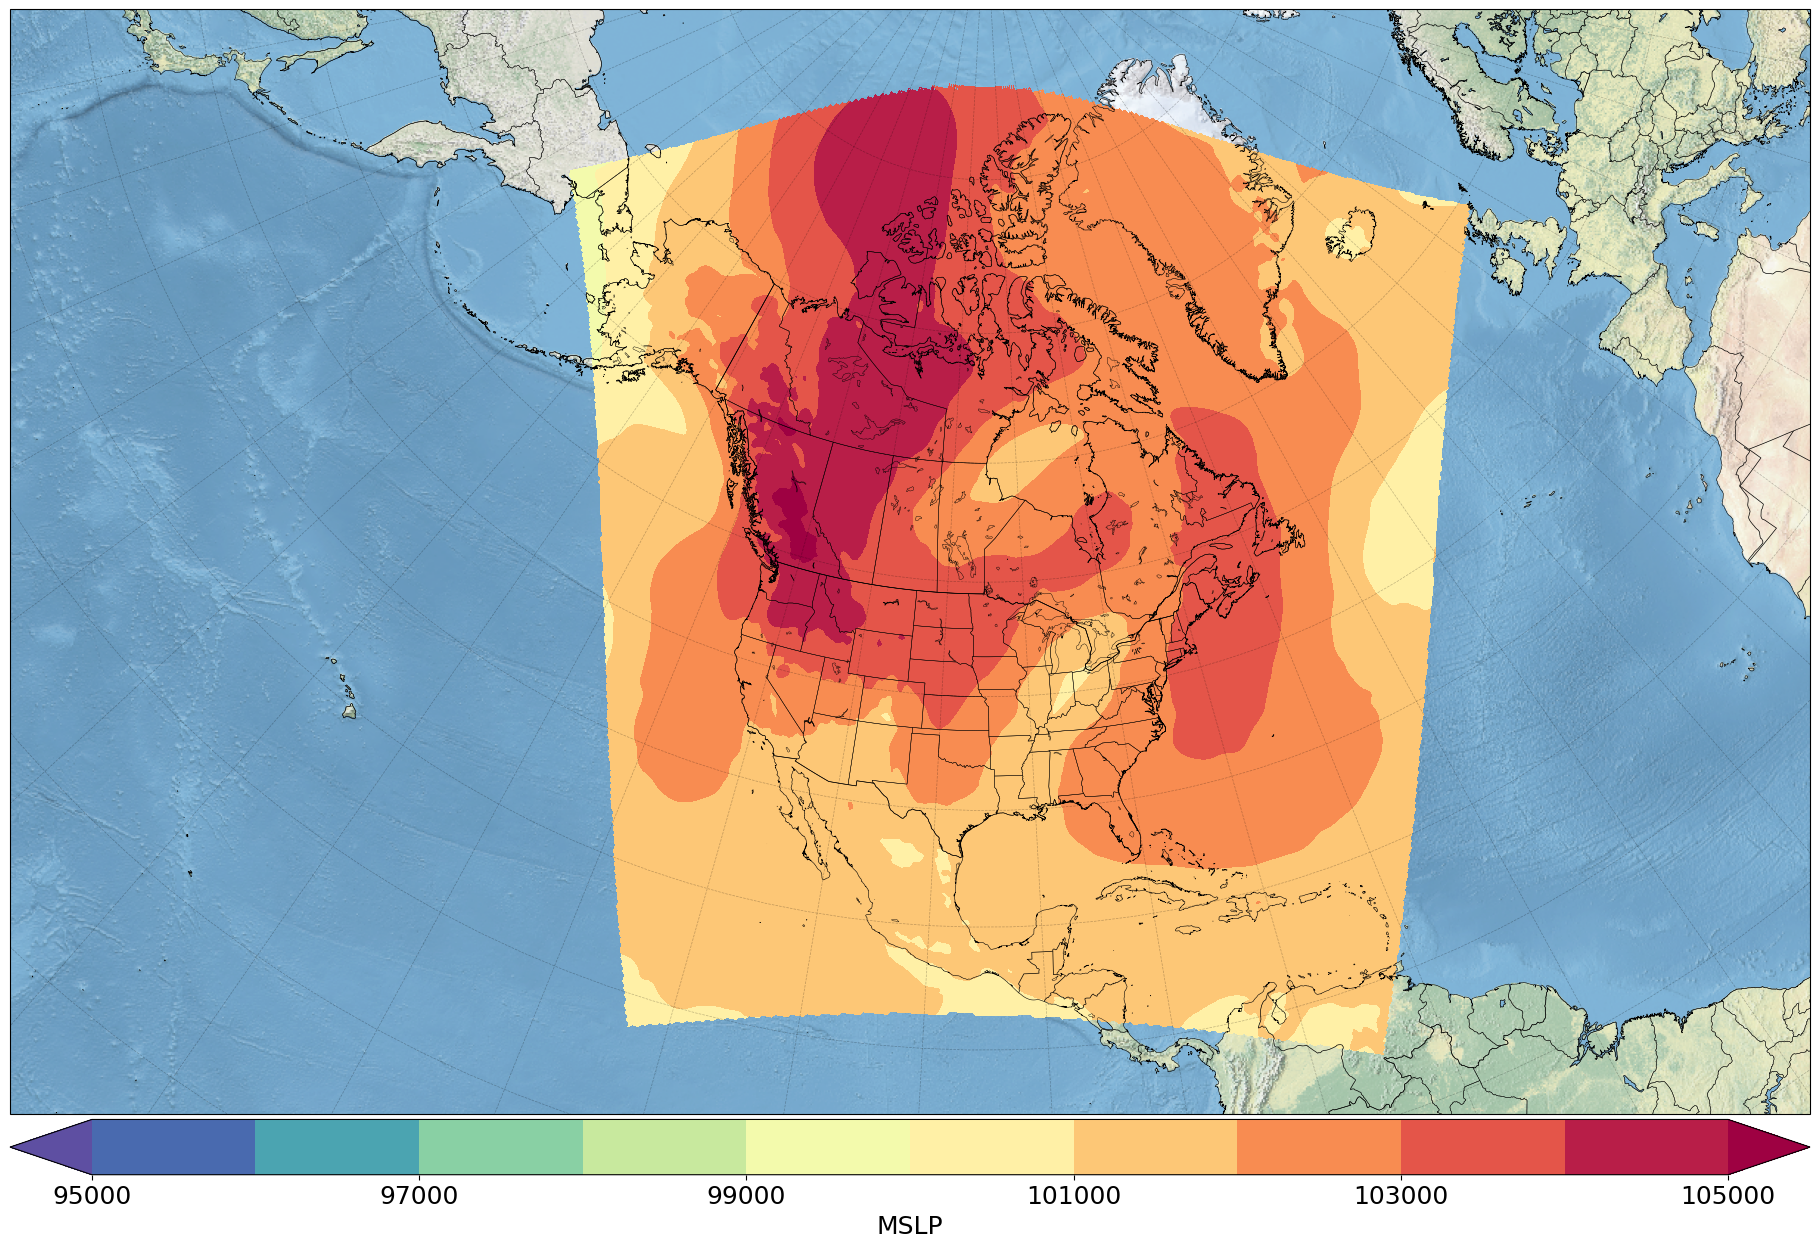

In [11]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(18, 16), tight_layout = {'pad': 0})

vmin = 95000
vmax = 105000
step = 1000

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-180, -27, 85, 5], crs=ccrs.PlateCarree())
borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes_color = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#7FB4D8', edgecolor='black')
lakes_edge = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='none', edgecolor='black')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes_color, zorder=1, linewidth=0.3)
ax.add_feature(lakes_edge, zorder=2, linewidth=0.3)
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

sc = ax.contourf(
    ds.longitude, ds.latitude, ds.isel(time=0).msl,
    transform=ccrs.PlateCarree(),
    levels=np.arange(vmin, vmax+step, step),
    cmap='Spectral_r',
    extend='both'
)

cbar = fig.colorbar(sc, cax=cax, orientation="horizontal", pad=0.02, aspect=20, extend='max')
cbar.set_label("MSLP", fontsize=18)
cbar.ax.tick_params(labelsize=18)

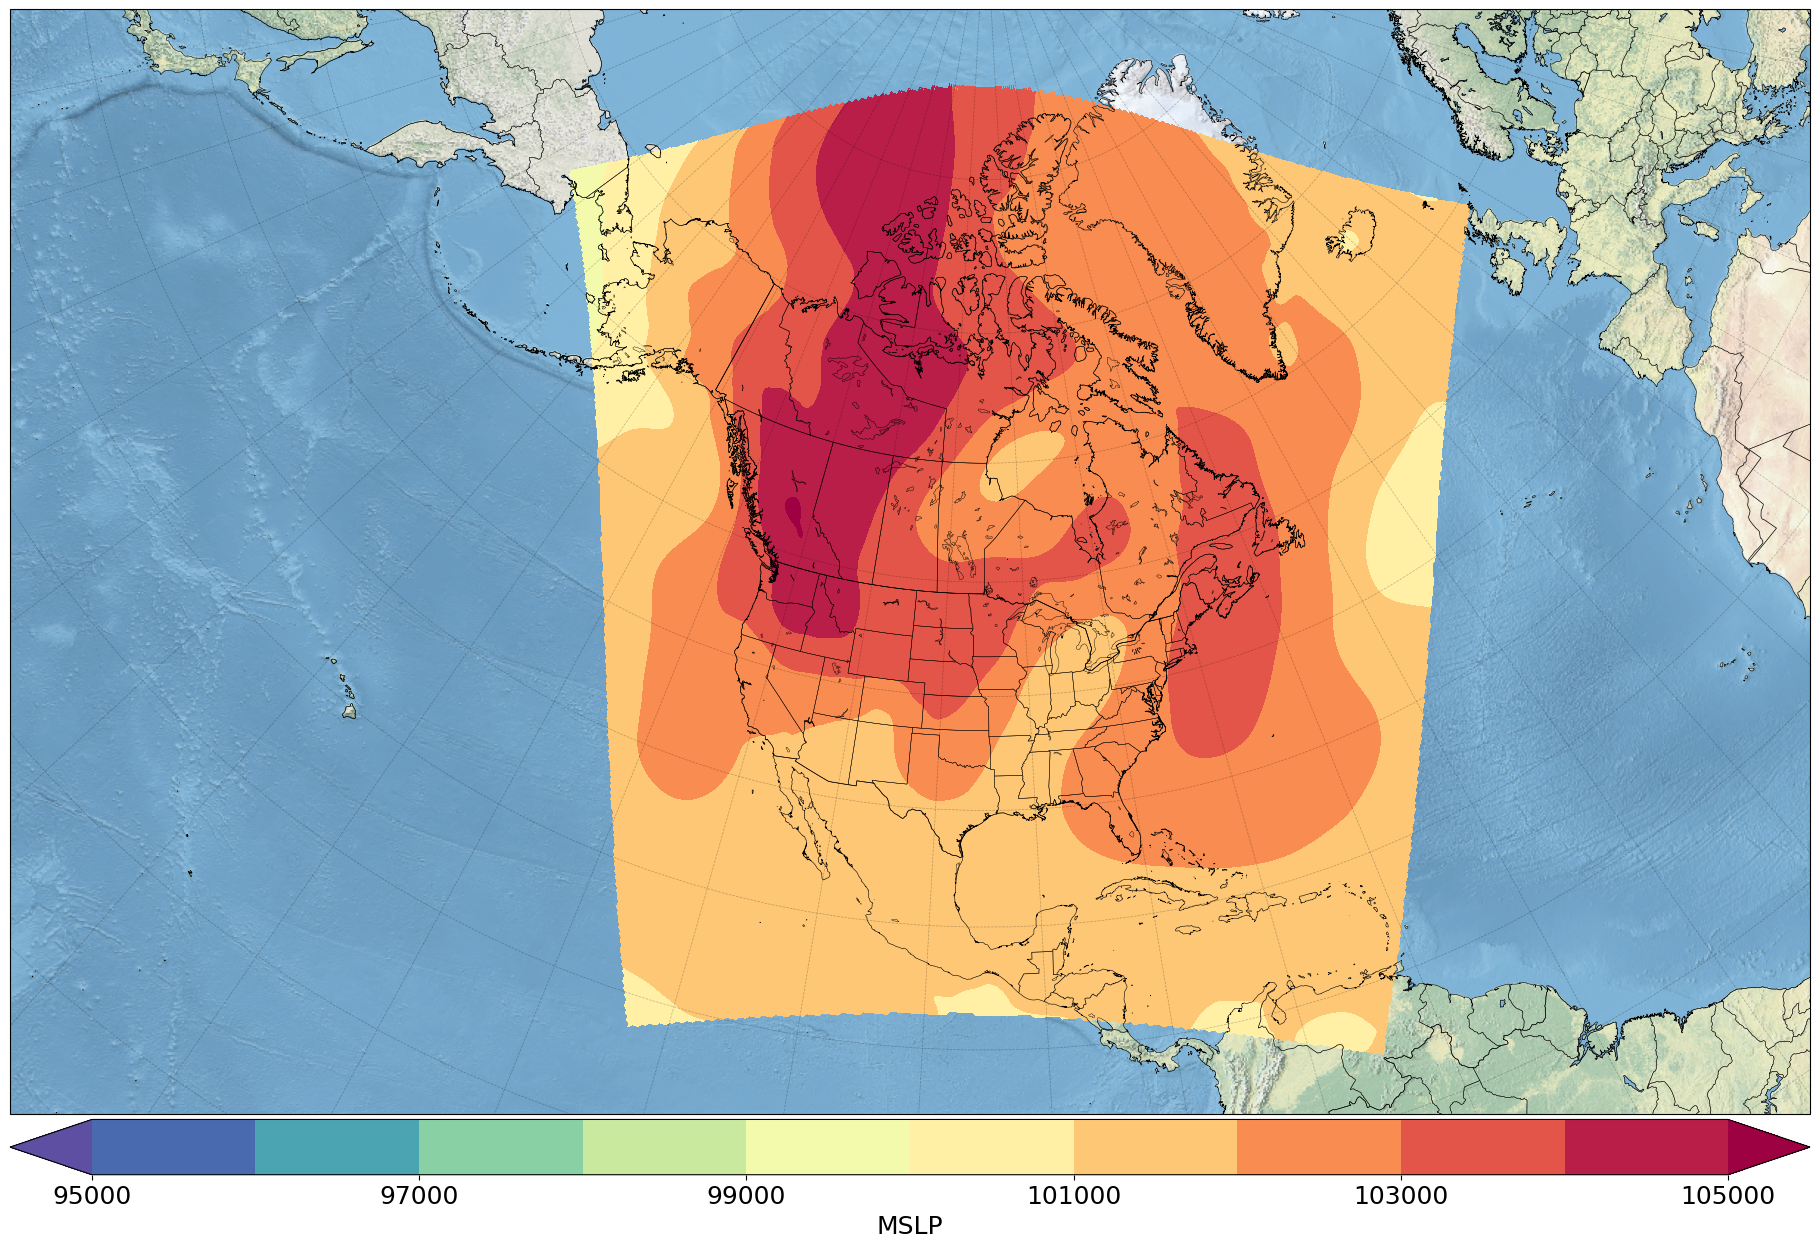

In [12]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(18, 16), tight_layout = {'pad': 0})

vmin = 95000
vmax = 105000
step = 1000

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-180, -27, 85, 5], crs=ccrs.PlateCarree())
borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes_color = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#7FB4D8', edgecolor='black')
lakes_edge = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='none', edgecolor='black')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes_color, zorder=1, linewidth=0.3)
ax.add_feature(lakes_edge, zorder=2, linewidth=0.3)
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

sc = ax.contourf(
    slp.longitude, slp.latitude, slp.isel(time=0),
    transform=ccrs.PlateCarree(),
    levels=np.arange(vmin, vmax+step, step),
    cmap='Spectral_r',
    extend='both'
)

cbar = fig.colorbar(sc, cax=cax, orientation="horizontal", pad=0.02, aspect=20, extend='max')
cbar.set_label("MSLP", fontsize=18)
cbar.ax.tick_params(labelsize=18)